In [9]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "pandas", "matplotlib", "-q"])

0

# ReproScore Analysis

This notebook analyses the results stored in the ReproScore pipeline database (`output/db/db.sqlite`).

**Sections:**
1. Setup & DB connection
2. Repository overview
3. Score distributions (RRS, RCS)
4. Notebook execution results
5. Reproducibility metrics
6. Error analysis
7. Summary statistics

## 1. Setup

In [10]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.2f}'.format)

DB_FILE = Path(__file__).resolve().parent.parent / 'output/db/db.sqlite' if '__file__' in dir() else Path.home() / 'output/db/db.sqlite'
assert DB_FILE.exists(), f'DB not found at {DB_FILE} — run the pipeline first.'

def load(query, **kwargs):
    with sqlite3.connect(DB_FILE) as con:
        return pd.read_sql_query(query, con, **kwargs)

print(f'Connected to {DB_FILE}')

Connected to /home/jovyan/output/db/db.sqlite


## 2. Repository Overview

In [11]:
repos = load("""
    SELECT
        r.id,
        r.repository,
        r.notebooks_count,
        r.rrs,
        r.score_E,
        r.score_A,
        r.score_D,
        r.score_C,
        r.score_S,
        r.rcs,
        rr.run_status,
        rr.duration_seconds
    FROM repo_targets r
    LEFT JOIN repository_runs rr ON rr.repository_id = r.id
    ORDER BY r.id
""")

print(f'Repositories scored: {len(repos)}')
repos

Repositories scored: 2


,id,repository,notebooks_count,rrs,score_E,score_A,score_D,score_C,score_S,rcs,run_status,duration_seconds
0,1,caravangelo/inflation-easy,2,18.54,0.00,34.00,67.56,65.00,67.80,18.54,SUCCESS,205.83
1,2,theislab/single-cell-tutorial,8,43.67,44.00,28.00,45.29,65.00,49.00,43.67,SUCCESS,209.94


## 3. Score Distributions

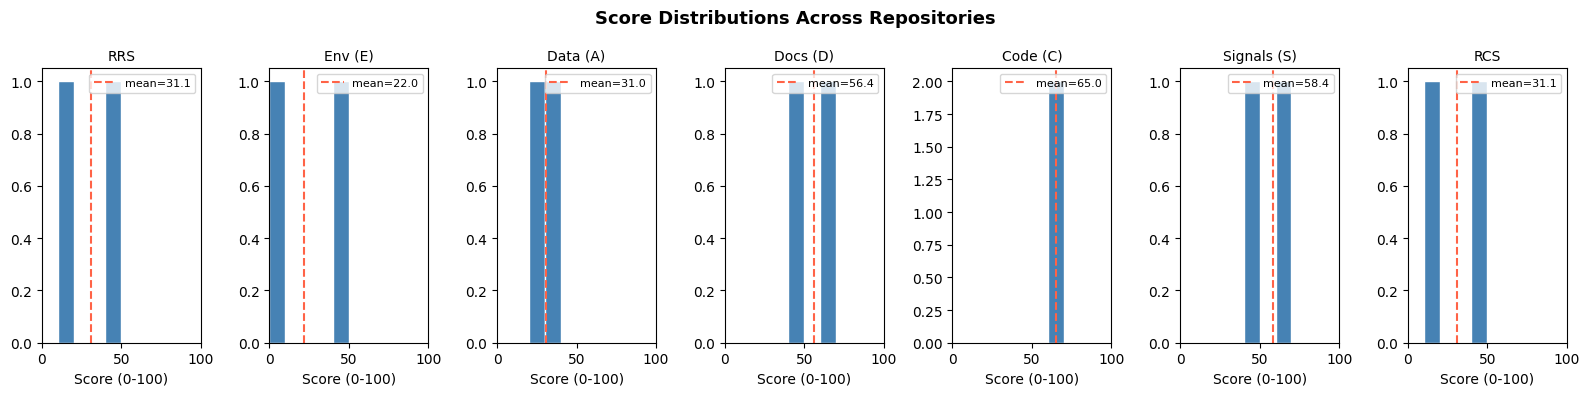

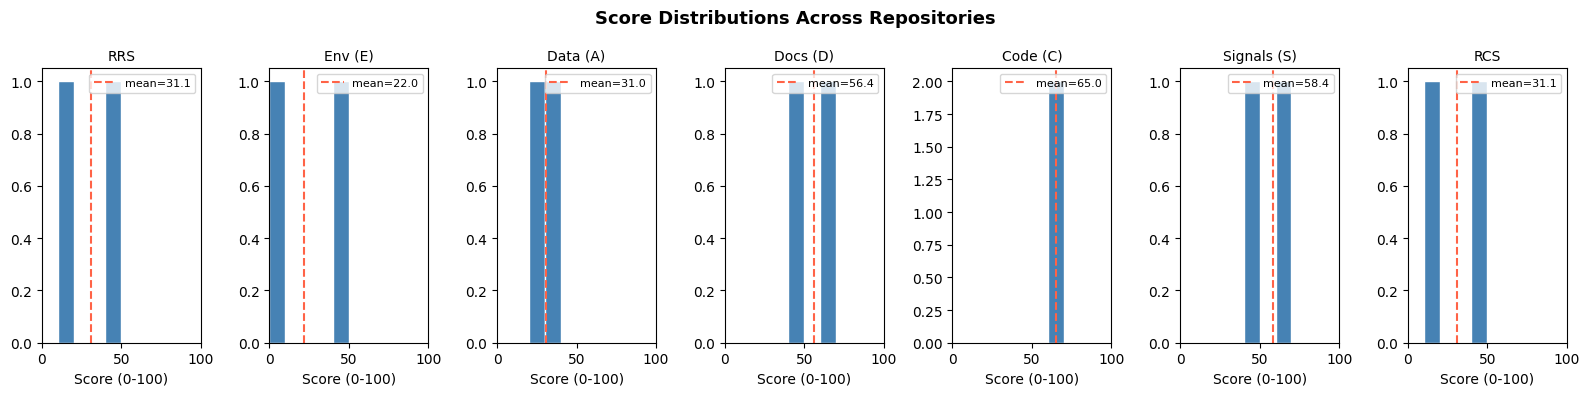

In [12]:
score_cols = ['rrs', 'score_E', 'score_A', 'score_D', 'score_C', 'score_S', 'rcs']
labels     = ['RRS', 'Env (E)', 'Data (A)', 'Docs (D)', 'Code (C)', 'Signals (S)', 'RCS']

scores = repos[score_cols].dropna(how='all')

fig, axes = plt.subplots(1, len(score_cols), figsize=(16, 4), sharey=False)
fig.suptitle('Score Distributions Across Repositories', fontsize=13, fontweight='bold')

for ax, col, label in zip(axes, score_cols, labels):
    data = scores[col].dropna()
    if data.empty:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label, fontsize=10)
        continue
    ax.hist(data, bins=10, range=(0, 100), color='steelblue', edgecolor='white')
    ax.axvline(data.mean(), color='tomato', linestyle='--', linewidth=1.5, label=f'mean={data.mean():.1f}')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score (0-100)')
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

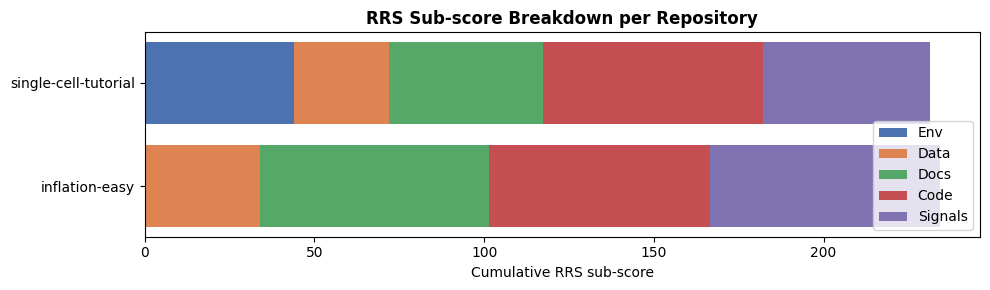

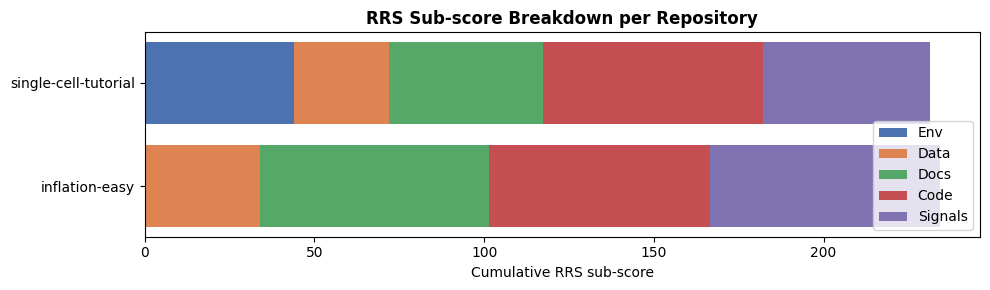

In [13]:
# RRS sub-score breakdown per repo
rrs_cols   = ['score_E', 'score_A', 'score_D', 'score_C', 'score_S']
rrs_labels = ['Env', 'Data', 'Docs', 'Code', 'Signals']
colors     = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

plot_data = repos[['repository'] + rrs_cols].dropna(subset=rrs_cols, how='all').copy()
plot_data['repository'] = plot_data['repository'].str.split('/').str[-1]

if not plot_data.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, len(plot_data) * 0.6)))
    bottom = [0] * len(plot_data)
    for col, label, color in zip(rrs_cols, rrs_labels, colors):
        vals = plot_data[col].fillna(0).tolist()
        ax.barh(plot_data['repository'], vals, left=bottom, label=label, color=color)
        bottom = [b + v for b, v in zip(bottom, vals)]
    ax.set_xlabel('Cumulative RRS sub-score')
    ax.set_title('RRS Sub-score Breakdown per Repository', fontweight='bold')
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print('No RRS sub-scores available yet.')

## 4. Notebook Execution Results

In [14]:
executions = load("""
    SELECT
        r.repository,
        ne.notebook_name,
        ne.execution_status,
        ne.total_code_cells,
        ne.executed_cells,
        ne.error_category,
        ne.error_message,
        ne.execution_duration
    FROM notebook_executions ne
    JOIN repo_targets r ON r.id = ne.repository_id
    ORDER BY r.repository, ne.notebook_name
""")

print(f'Total notebook executions: {len(executions)}')
executions[['repository','notebook_name','execution_status','total_code_cells','error_category','execution_duration']]

Total notebook executions: 10


,repository,notebook_name,execution_status,total_code_cells,error_category,execution_duration
0,caravangelo/inflation-easy,notebooks/plot.ipynb,SUCCESS_WITH_ERRORS,14,FILE_ERROR,None
1,caravangelo/inflation-easy,notebooks/quickstart.ipynb,SUCCESS_WITH_ERRORS,15,OTHER_ERROR,None
2,theislab/single-cell-tutorial,latest_notebook/Case-study_Mouse-intestinal-epithelium_1...,SUCCESS_WITH_ERRORS,119,DEPENDENCY_ERROR,None
3,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1902...,SUCCESS_WITH_ERRORS,120,DEPENDENCY_ERROR,None
4,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1903...,SUCCESS_WITH_ERRORS,119,DEPENDENCY_ERROR,None
5,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1903...,SUCCESS_WITH_ERRORS,118,DEPENDENCY_ERROR,None
6,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1904...,SUCCESS_WITH_ERRORS,119,DEPENDENCY_ERROR,None
7,theislab/single-cell-tutorial,plotting_scripts/Klein_data_batch_effects_denoising.ipynb,SUCCESS_WITH_ERRORS,36,DEPENDENCY_ERROR,None
8,theislab/single-cell-tutorial,plotting_scripts/QC_plots.ipynb,SUCCESS_WITH_ERRORS,16,DEPENDENCY_ERROR,None
9,theislab/single-cell-tutorial,supplementary_scripts/Splatter-marker-genes-random-data....,SUCCESS_WITH_ERRORS,19,DEPENDENCY_ERROR,None


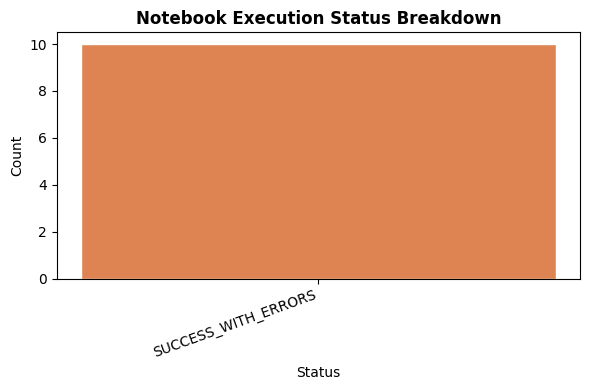

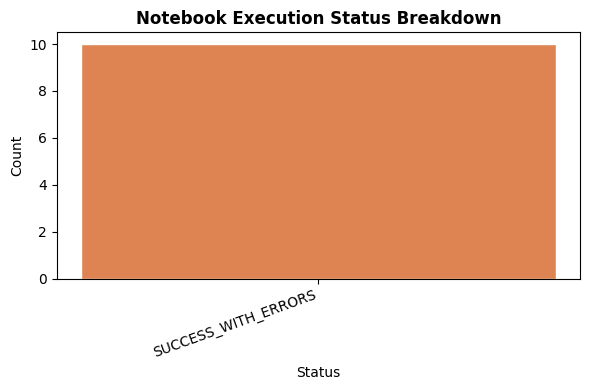

In [15]:
status_counts = executions['execution_status'].value_counts()

status_colors = {
    'SUCCESS': '#55A868',
    'SUCCESS_WITH_ERRORS': '#DD8452',
    'FAILED': '#C44E52',
    'TIMEOUT': '#8172B2',
    'FILE_ERROR': '#937860',
    'OTHER_ERROR': '#DA8BC3',
}
bar_colors = [status_colors.get(s, 'grey') for s in status_counts.index]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(status_counts.index, status_counts.values, color=bar_colors, edgecolor='white')
ax.set_title('Notebook Execution Status Breakdown', fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Status')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 5. Reproducibility Metrics

Metrics for 10 notebooks


,repository,notebook,total_code_cells,identical_cells_count,different_cells_count,nondeterministic_cells_count,reproducibility_score
0,caravangelo/inflation-easy,notebooks/plot.ipynb,14,4,10,0,0.29
1,caravangelo/inflation-easy,notebooks/quickstart.ipynb,15,5,10,0,0.33
2,theislab/single-cell-tutorial,latest_notebook/Case-study_Mouse-intestinal-epithelium_1...,119,5,114,0,0.04
3,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1902...,120,4,116,0,0.03
4,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1903...,119,5,114,0,0.04
5,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1903...,118,4,114,0,0.03
6,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1904...,119,5,114,0,0.04
7,theislab/single-cell-tutorial,plotting_scripts/Klein_data_batch_effects_denoising.ipynb,36,1,35,0,0.03
8,theislab/single-cell-tutorial,plotting_scripts/QC_plots.ipynb,16,2,14,0,0.12
9,theislab/single-cell-tutorial,supplementary_scripts/Splatter-marker-genes-random-data....,19,0,19,0,0.00


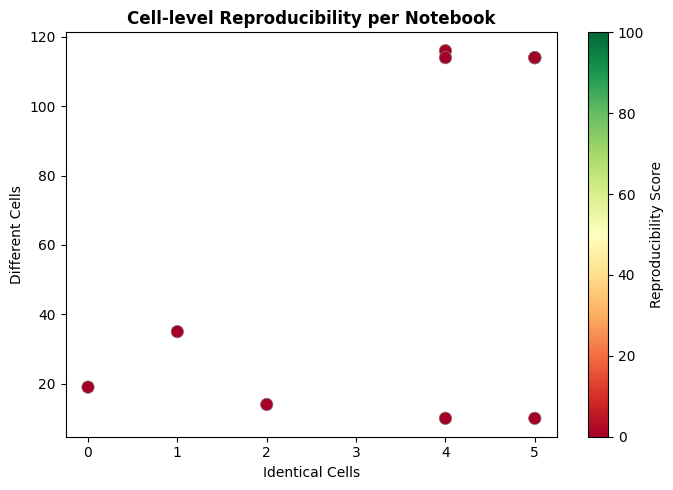

In [16]:
metrics = load("""
    SELECT
        r.repository,
        n.name AS notebook,
        m.total_code_cells,
        m.identical_cells_count,
        m.different_cells_count,
        m.nondeterministic_cells_count,
        m.reproducibility_score
    FROM notebook_reproducibility_metrics m
    JOIN repo_targets r ON r.id = m.repository_id
    JOIN notebooks n ON n.id = m.notebook_id
    ORDER BY r.repository, n.name
""")

if metrics.empty:
    print('No reproducibility metrics yet.')
else:
    print(f'Metrics for {len(metrics)} notebooks')
    display(metrics)

    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(
        metrics['identical_cells_count'],
        metrics['different_cells_count'],
        c=metrics['reproducibility_score'],
        cmap='RdYlGn', vmin=0, vmax=100, s=80, edgecolors='grey', linewidths=0.5
    )
    plt.colorbar(scatter, ax=ax, label='Reproducibility Score')
    ax.set_xlabel('Identical Cells')
    ax.set_ylabel('Different Cells')
    ax.set_title('Cell-level Reproducibility per Notebook', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Error Analysis

Notebooks with errors: 10


,repository,notebook_name,error_category,error_message
0,caravangelo/inflation-easy,notebooks/plot.ipynb,FILE_ERROR,[Errno 2] No such file or directory: '../results/spectra...
1,caravangelo/inflation-easy,notebooks/quickstart.ipynb,OTHER_ERROR,Failed to process string with tex because latex could no...
2,theislab/single-cell-tutorial,latest_notebook/Case-study_Mouse-intestinal-epithelium_1...,DEPENDENCY_ERROR,cannot import name 'GProfiler' from 'gprofiler' (/home/j...
3,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1902...,DEPENDENCY_ERROR,No module named 'scanpy.api'
4,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1903...,DEPENDENCY_ERROR,No module named 'rpy2'
5,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1903...,DEPENDENCY_ERROR,No module named 'rpy2'
6,theislab/single-cell-tutorial,old_releases/Case-study_Mouse-intestinal-epithelium_1904...,DEPENDENCY_ERROR,No module named 'rpy2'
7,theislab/single-cell-tutorial,plotting_scripts/Klein_data_batch_effects_denoising.ipynb,DEPENDENCY_ERROR,No module named 'scanpy.api'
8,theislab/single-cell-tutorial,plotting_scripts/QC_plots.ipynb,DEPENDENCY_ERROR,No module named 'scanpy.api'
9,theislab/single-cell-tutorial,supplementary_scripts/Splatter-marker-genes-random-data....,DEPENDENCY_ERROR,No module named 'scanpy.api'


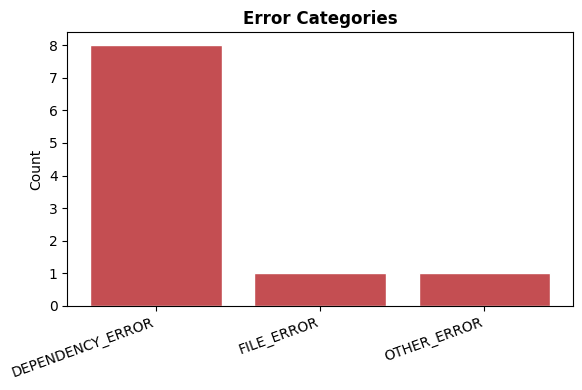

In [17]:
errors = executions[executions['error_category'].notna()][[
    'repository', 'notebook_name', 'error_category', 'error_message'
]].copy()

if errors.empty:
    print('No errors recorded.')
else:
    print(f'Notebooks with errors: {len(errors)}')
    display(errors)

    err_counts = errors['error_category'].value_counts()
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(err_counts.index, err_counts.values, color='#C44E52', edgecolor='white')
    ax.set_title('Error Categories', fontweight='bold')
    ax.set_ylabel('Count')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Summary Statistics

In [18]:
print('=' * 45)
print('  REPROSCORE PIPELINE SUMMARY')
print('=' * 45)
print(f'  Repositories scored : {len(repos)}')
print(f'  Notebooks executed  : {len(executions)}')

if not repos['rrs'].dropna().empty:
    print(f'  Mean RRS            : {repos["rrs"].mean():.1f}')
    print(f'  Min  RRS            : {repos["rrs"].min():.1f}')
    print(f'  Max  RRS            : {repos["rrs"].max():.1f}')

if not repos['rcs'].dropna().empty:
    print(f'  Mean RCS            : {repos["rcs"].mean():.1f}')

status_summary = executions['execution_status'].value_counts().to_dict()
for status, count in status_summary.items():
    print(f'  {status:<22}: {count}')
print('=' * 45)

  REPROSCORE PIPELINE SUMMARY
  Repositories scored : 2
  Notebooks executed  : 10
  Mean RRS            : 31.1
  Min  RRS            : 18.5
  Max  RRS            : 43.7
  Mean RCS            : 31.1
  SUCCESS_WITH_ERRORS   : 10
